In [2]:
from scipy import integrate
import numpy as np
from numpy import pi
import pickle

integrate.quad(np.cos, 0.0, np.pi/2)


(0.9999999999999999, 1.1102230246251564e-14)

In [3]:
integrate.quadrature(np.cos, 0.0, np.pi/2)

(0.9999999999999536, 3.9611425250996035e-11)

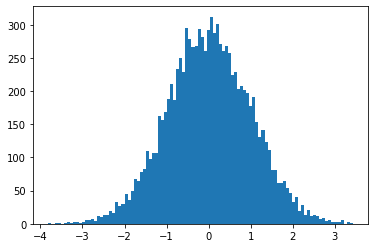

In [4]:
import numpy.random as random
import matplotlib.pyplot as plt
a = random.normal(size=10000)
plt.hist(a, bins=100); # nonrepeating seed initiated by default

<b> Monte Carlo </b> <br>
Better for large numbers of dimensions
Need very good random numbers, otherwise biased e.g. clustering along some hyperplanes
Convergence improved by taking more samples where integrand value larger
- Few samples to estimate value + error in each subregion
- Decide how to optimally divide samples within each region
- Subdivide regions and repeat, recursion

# <b> Core Task 2 </b>: Calculating Fresenel integrals

In [5]:
# Defining the Fresnel integrals

def cfunc(x):
    return np.cos(pi*x**2/2)

def sfunc(x):
    return np.sin(pi*x**2/2)

def C(u):
    return integrate.quad(cfunc, 0, u)[0]

def S(u):
    return integrate.quad(sfunc, 0, u)[0]

In [6]:
C = np.vectorize(C)
S = np.vectorize(S)

In [7]:
end = 20
points = 2000
u = np.linspace(-end, end, points)
x = C(u)
y = S(u)

<ipython-input-5-0388554b6a22>:10: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(cfunc, 0, u)[0]
<ipython-input-5-0388554b6a22>:13: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose int

In [8]:
cornu_data = {"x": x, "y": y}
pickle_out = open("cornu_dict.pickle", "wb")
pickle.dump(cornu_data, pickle_out)
pickle_out.close()

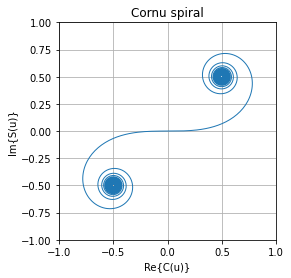

In [9]:
plt.plot(x, y, lw='1')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.gca().set_aspect("equal")
plt.title("Cornu spiral")
plt.xlabel("Re{C(u)}")
plt.ylabel("Im{S(u)}")
plt.grid()

# <b> Supplementary task 2: </b> Diffraction pattern

In [10]:
# Defining variables
d = 0.1 # Slit width; integrate from -d/2 to d/2
lam = 0.01 # Wavelength
#D = 1 # Distance from slit to screen

In [11]:
def diffracted(x, d, lam, D):
    """
    Returns a tuple (diffracted amplitude, relative phase) at a point <D> away from 
    the slit that is collinear with the source and a point <x> away from the centre
    of the slit (of width <d>), for light of wavelength <lam>.  
    """
    # Calculating upper/lower bounds wrt origin at x
    upper = d/2 - x
    lower = -d/2 - x
    
    # Transform to Fresnel coordinates
    w2 = np.sqrt(2/(lam*D)) * upper  
    w1 = np.sqrt(2/(lam*D)) * lower
    
    real = C(w2) - C(w1)
    im = S(w2) - S(w1)
    return (real**2 + im**2, np.arctan(im/real))

In [12]:
# Function returning the diffraction pattern and phases at observation points
# given by the array x
def fresnel(x, D):
    amplitudes = []
    phases = []
    for i in x:
        result = diffracted(i, d, lam, D)
        amplitudes.append(result[0])
        phases.append(result[1])
    amplitudes = np.array(amplitudes)/max(amplitudes)
    return (amplitudes, phases)

In [ ]:
# Calculating the diffraction amplitudes and phases for different D
x = np.linspace(-0.5, 0.5, 500)

data = []
for D in [0.3, 0.5, 1]:
    data.append(fresnel(x, D)) 

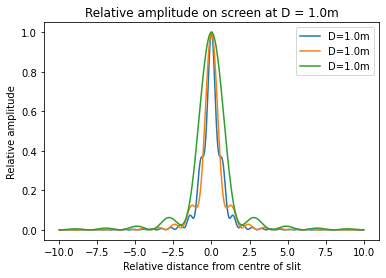

In [ ]:
# Plot amplitudes
for i in range(3):
    plt.plot(x/(d/2), data[i][0], label=f"D={D:.1f}m")

plt.title(f"Relative amplitude on screen at D = {D:.1f}m")
plt.ylabel("Relative amplitude")
plt.xlabel("Relative distance from centre of slit")
plt.legend();

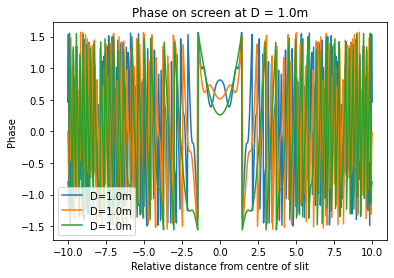

In [ ]:
# Plot phases
for i in range(3):
    plt.plot(x/(d/2), data[i][1], label=f"D={D:.1f}m")

plt.title(f"Phase on screen at D = {D:.1f}m")
plt.ylabel("Phase")
plt.xlabel("Relative distance from centre of slit")
plt.legend();

In [ ]:
data = {1:"6",2:"2",3:"f"}
pickle_out = open("dict.pickle", "wb")
pickle.dump(data, pickle_out)
pickle_out.close()

In [ ]:
pickle_in = open("dict.pickle", "rb")
example = pickle.load(pickle_in)